# Seasonal Agriculture Performance Analysis

## VOIS AICTE Batch 1 2026–2027 — Major Project

### 1. Introduction

Agricultural performance is influenced by several factors, including seasonal conditions, environmental characteristics, farming practices, resource utilization, geographical conditions, and economic factors.

This project focuses on analyzing agricultural data collected across different seasons, regions, crops, and farming conditions. The analysis aims to understand how agricultural performance changes across seasons and to identify meaningful patterns, trends, relationships, variations, and unusual observations within the dataset.

The project applies data analytics techniques such as data cleaning, exploratory data analysis, statistical analysis, correlation analysis, and data visualization to derive evidence-based insights from the available agricultural data.

### 2. Problem Statement

Agricultural activities are affected by seasonal variations in environmental conditions, farming practices, resource availability, and economic conditions. Consequently, agricultural performance may differ across seasons.

However, raw agricultural data does not directly reveal how these factors vary between seasons or how seasonal conditions are associated with agricultural outcomes.

Therefore, this project analyzes the given agricultural dataset to investigate seasonal differences in agricultural performance and identify meaningful patterns, trends, relationships, and variations.

### 3. Objectives

The major objectives of this project are:

* To understand the structure and characteristics of the agricultural dataset.
* To clean and prepare the dataset for analysis.
* To examine agricultural performance across different seasons.
* To compare crop yield and production across seasons.
* To analyze seasonal variations in environmental conditions.
* To examine resource utilization across seasons.
* To analyze economic performance across seasons.
* To investigate relationships between environmental conditions, resource usage, and agricultural outcomes.
* To identify significant differences and unusual patterns.
* To develop evidence-based insights and recommendations for seasonal agricultural planning.

### 4. Expected Outcomes

The project is expected to provide:

* An understanding of seasonal agricultural patterns.
* Comparisons of agricultural performance across seasons.
* Insights into environmental and resource variations.
* Analysis of economic performance across seasons.
* Identification of important relationships between variables.
* Statistically supported findings where appropriate.
* Evidence-based recommendations for agricultural planning.


## 1. Project Overview

Agricultural performance can vary across seasons due to differences in environmental conditions, farming practices, resource availability, and economic factors.

This project analyzes agricultural data across Kharif, Rabi, and Zaid seasons to identify seasonal patterns in productivity, resource usage, environmental conditions, and economic performance.

The analysis uses data cleaning, exploratory data analysis, statistical analysis, correlation analysis, and data visualization techniques.

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [53]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (1).csv


In [54]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 4000
Number of columns: 28


## 5. Dataset Understanding

Before performing data cleaning and analysis, it is important to understand the structure and characteristics of the dataset.

This section examines the first few records, column names, data types, dataset dimensions, unique values, and basic statistical information.

Understanding the dataset helps identify the variables available for seasonal agricultural performance analysis and provides a foundation for the subsequent data preparation and exploratory analysis.

In [55]:
# Display the first 5 rows of the dataset

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [56]:
# Display all column names

print("Column Names:")
print()

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Column Names:

1. Farm_ID
2. State
3. District
4. Crop
5. Season
6. Farm_Area_Hectares
7. Rainfall_mm
8. Avg_Temperature_C
9. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct


In [57]:
# Check data types and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [58]:
# Statistical summary of numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [59]:
# Number of unique values in each column

df.nunique().sort_values()

,0
Season,3
Irrigation_Method,4
Crop,8
State,8
District,10
Seed_Quality_Score,36
Sunlight_Hours_Day,71
Avg_Temperature_C,204
Soil_pH,313
Soil_Moisture_pct,343


## 6. Data Cleaning and Preprocessing

Data cleaning is an important step before performing analysis. It helps improve the quality and reliability of the results.

In this section, the dataset will be checked for:

- Missing values
- Duplicate records
- Incorrect data types
- Inconsistent categorical values
- Potential outliers

The appropriate treatment will be selected based on the characteristics of each variable.

In [60]:
# Check missing values in each column

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


In [61]:
# Calculate percentage of missing values

missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_summary[missing_summary['Missing Values'] > 0]

,Missing Values,Missing Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [62]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [63]:
# Check unique values of important categorical columns

categorical_columns = [
    'State',
    'District',
    'Crop',
    'Season',
    'Irrigation_Method'
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


State:
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [64]:
# Handle missing values using median imputation

columns_to_impute = [
    'Rainfall_mm',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha'
]

for column in columns_to_impute:
    df[column] = df[column].fillna(df[column].median())

print("Missing values handled successfully!")

Missing values handled successfully!


In [65]:
# Verify missing values after cleaning

missing_after = df.isnull().sum()

print("Missing values after cleaning:")

if missing_after.sum() == 0:
    print("No missing values found.")
else:
    print(missing_after[missing_after > 0])

Missing values after cleaning:
No missing values found.


In [66]:
# Verify duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 7. Outlier Detection

Outlier detection is performed to identify unusually high or low observations in numerical variables.

Outliers may represent genuine variations in agricultural conditions, such as unusually high rainfall, production, yield, resource usage, or economic performance. Therefore, detected outliers will be investigated rather than automatically removed.

The Interquartile Range (IQR) method is used to identify potential outliers.

In [67]:
# Identify numerical columns

numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(list(numerical_columns))
print("\nNumber of numerical columns:", len(numerical_columns))

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Number of numerical columns: 22


In [68]:
# Detect potential outliers using the IQR method

outlier_summary = []

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        'Column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier Percentage': (len(outliers) / len(df)) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    by='Outlier Count',
    ascending=False
)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
18,Profit_INR,-148731.750,216187.75000,364919.50000,-696111.000000,7.635670e+05,404,10.100
14,Production_Tonnes,5.020,24.35500,19.33500,-23.982500,5.335750e+01,333,8.325
20,Water_Efficiency_t_per_1000m3,1.661,5.15025,3.48925,-3.572875,1.038412e+01,322,8.050
13,Yield_Tonnes_Ha,1.050,2.83000,1.78000,-1.620000,5.500000e+00,302,7.550
19,Water_Used_m3,2268.750,7829.75000,5561.00000,-6072.750000,1.617125e+04,276,6.900
17,Revenue_INR,207517.250,836874.75000,629357.50000,-736519.000000,1.780911e+06,240,6.000
9,Potassium_kg_ha,86.200,123.60000,37.40000,30.100000,1.797000e+02,32,0.800
4,Sunlight_Hours_Day,6.600,8.10000,1.50000,4.350000,1.035000e+01,26,0.650
8,Phosphorus_kg_ha,46.200,69.40000,23.20000,11.400000,1.042000e+02,16,0.400
10,Fertilizer_kg_ha,143.975,227.20000,83.22500,19.137500,3.520375e+02,15,0.375


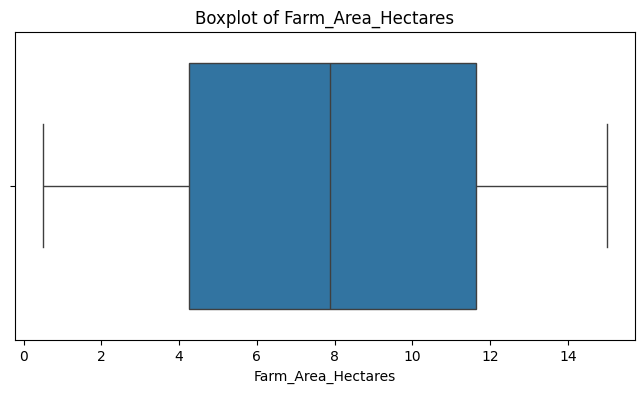

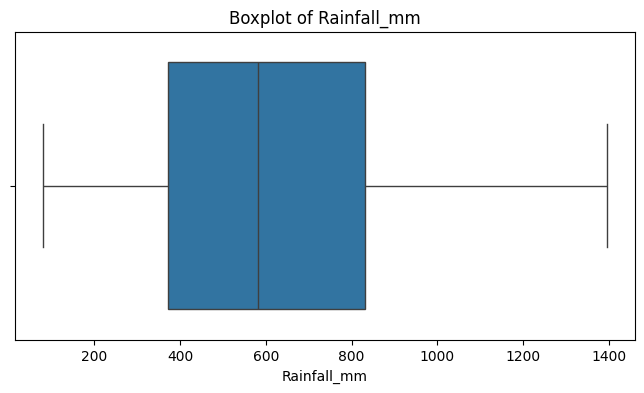

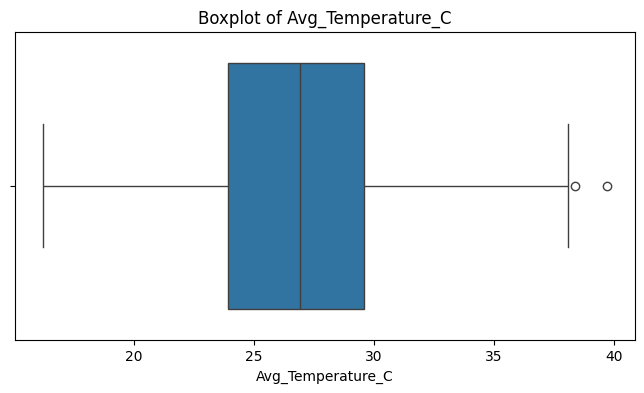

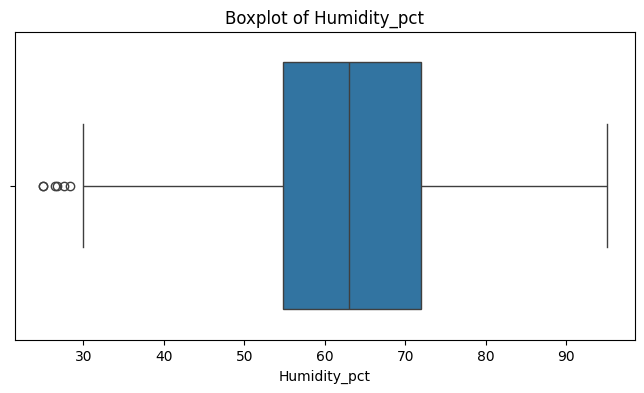

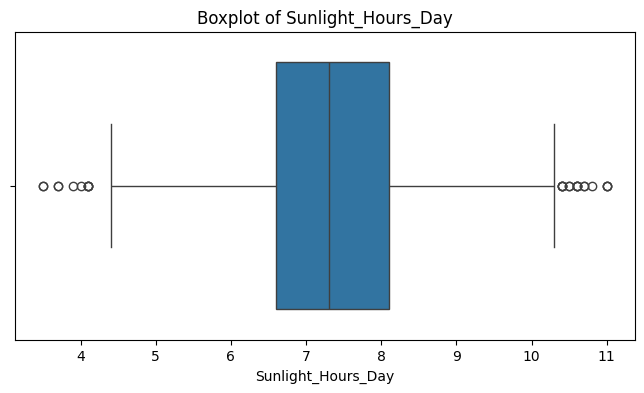

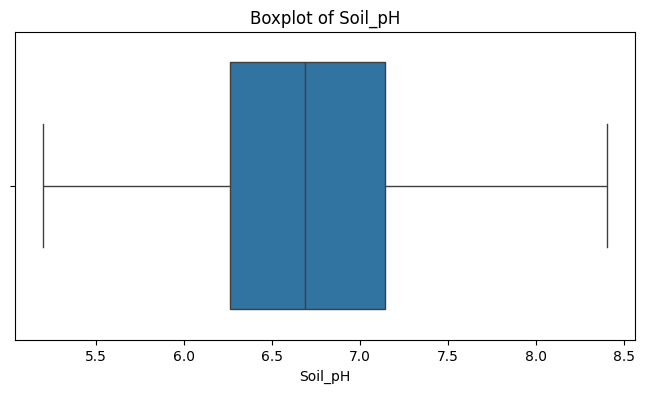

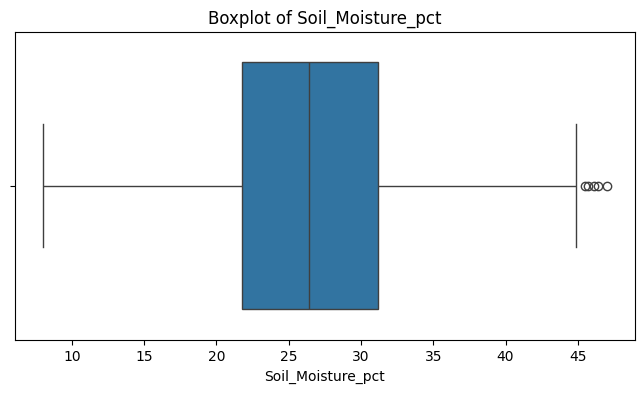

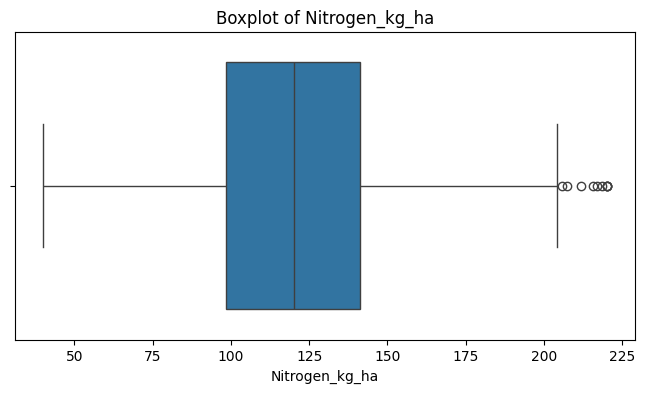

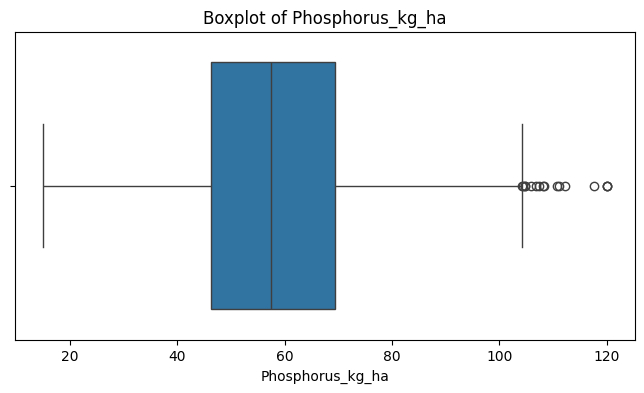

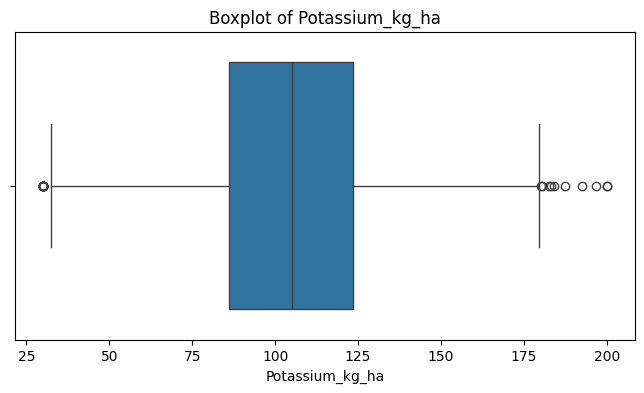

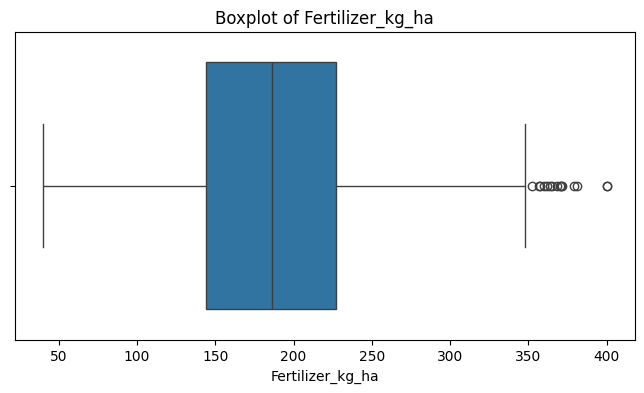

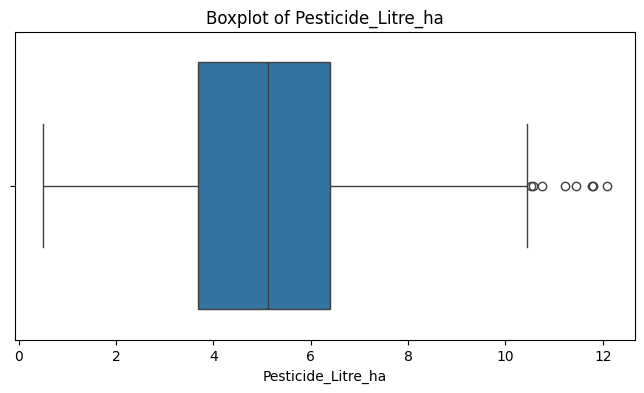

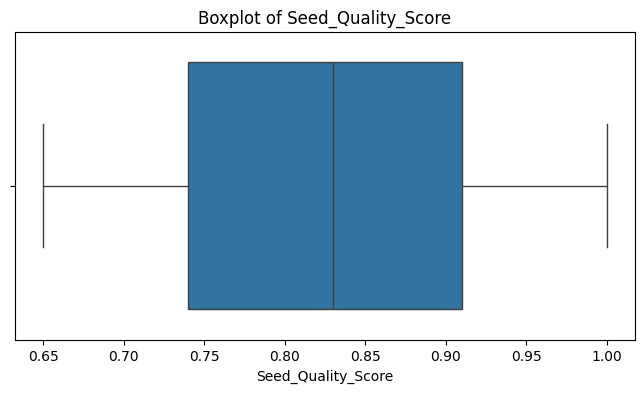

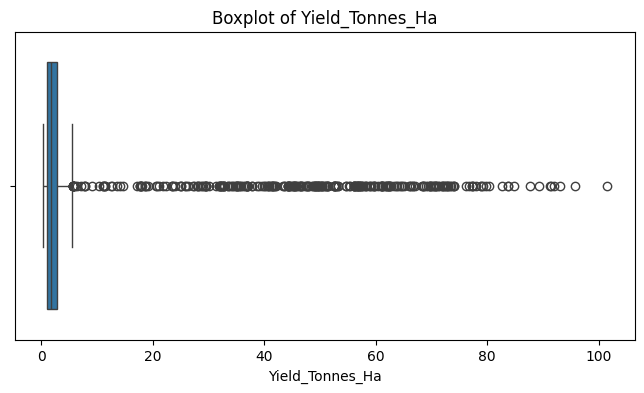

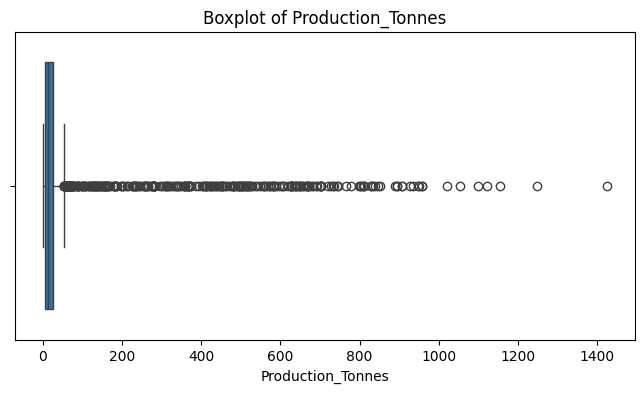

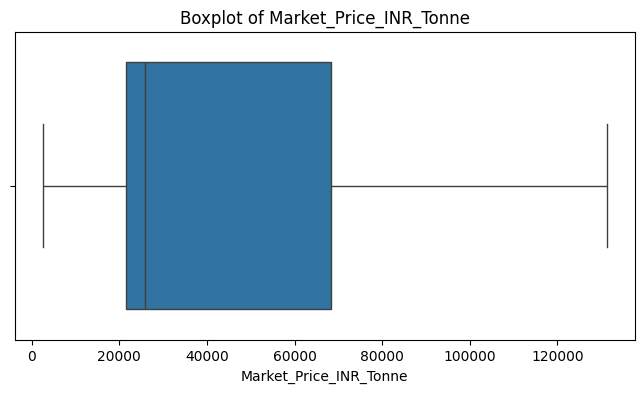

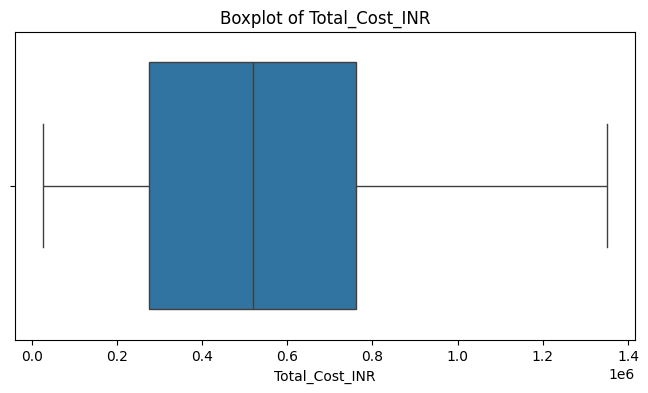

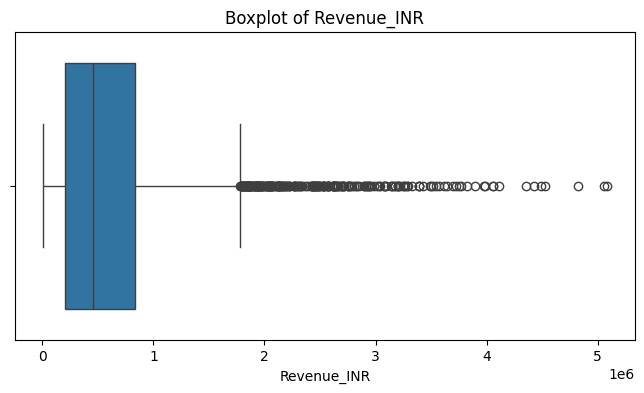

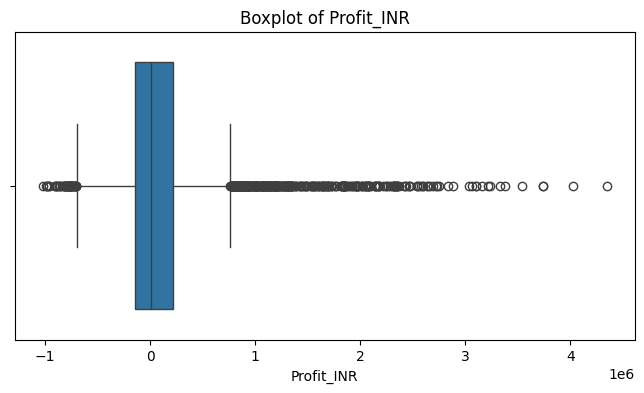

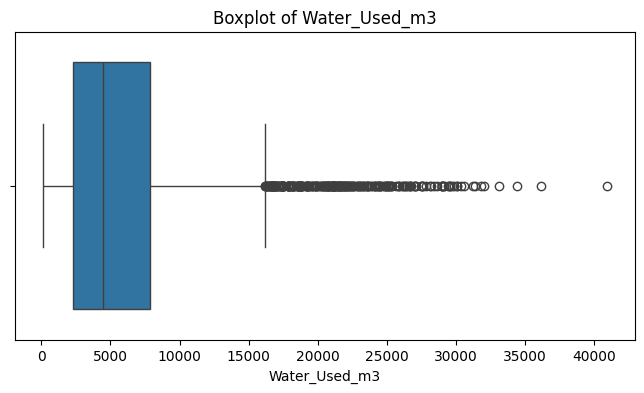

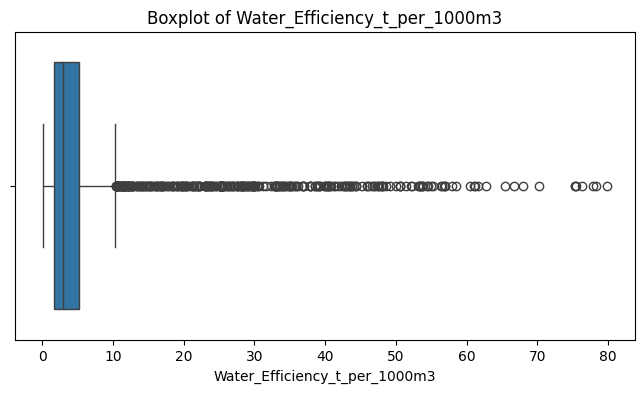

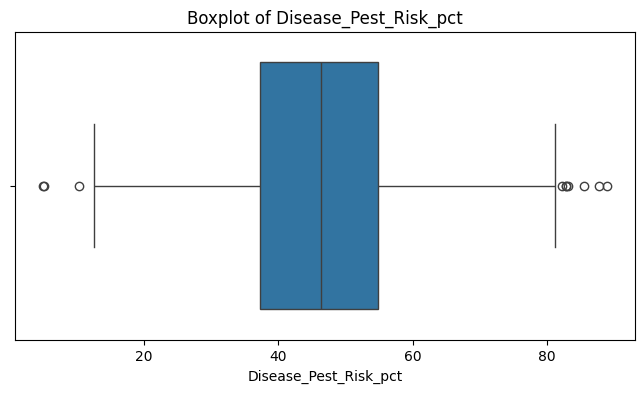

In [69]:
# Create boxplots for numerical variables

for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

In [70]:
outlier_df[['Column', 'Outlier Count', 'Outlier Percentage']]

,Column,Outlier Count,Outlier Percentage
0,Farm_Area_Hectares,0,0.000
1,Rainfall_mm,0,0.000
2,Avg_Temperature_C,2,0.050
3,Humidity_pct,6,0.150
4,Sunlight_Hours_Day,26,0.650
5,Soil_pH,0,0.000
6,Soil_Moisture_pct,5,0.125
7,Nitrogen_kg_ha,10,0.250
8,Phosphorus_kg_ha,16,0.400
9,Potassium_kg_ha,32,0.800


### Outlier Treatment Decision

The IQR method identified potential outliers in several numerical variables, particularly Yield, Production, Revenue, Profit, Water Used, and Water Efficiency.

These observations were not automatically removed because they may represent genuine differences in farm size, agricultural productivity, resource utilization, or economic performance.

Since the purpose of this project is to investigate variations in agricultural performance across seasons, retaining these observations allows the analysis to capture the natural variability present in the dataset.

Therefore, the identified outliers are retained for further analysis.

## 8. Seasonal Analysis

Season is the primary grouping variable in this project. The agricultural records are divided into three seasons: Kharif, Rabi, and Zaid.

The seasonal analysis compares agricultural performance, environmental conditions, resource utilization, and economic outcomes across these three seasons.

In [71]:
# Count the number of records in each season

season_counts = df['Season'].value_counts()

print("Number of records by season:")
print(season_counts)

Number of records by season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


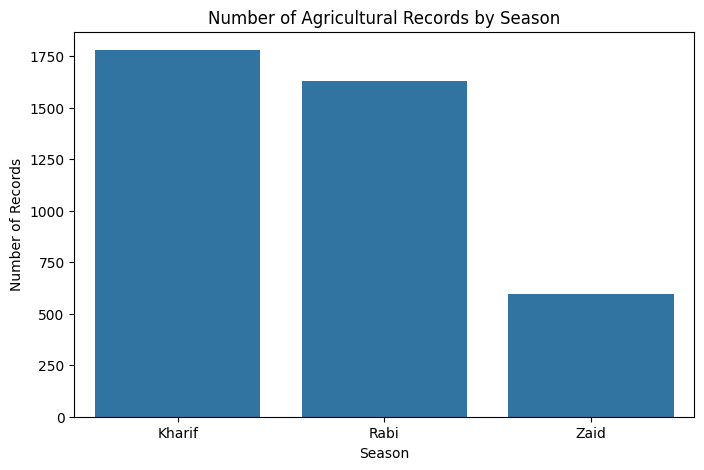

In [72]:
# Visualize the number of records by season

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Season')

plt.title('Number of Agricultural Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')

plt.show()

In [73]:
# Calculate percentage distribution of records by season

season_percentage = (
    df['Season']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Percentage distribution by season:")
print(season_percentage)

Percentage distribution by season:
Season
Kharif    44.47
Rabi      40.67
Zaid      14.85
Name: proportion, dtype: float64


## 9. Agricultural Performance Across Seasons

Agricultural performance is evaluated by comparing key productivity, economic, and resource-related indicators across Kharif, Rabi, and Zaid seasons.

The analysis focuses on average Yield, Production, Revenue, Profit, Water Used, and Water Efficiency to identify differences in agricultural performance between seasons.

In [74]:
# Calculate average agricultural performance by season

season_performance = df.groupby('Season')[
    [
        'Yield_Tonnes_Ha',
        'Production_Tonnes',
        'Revenue_INR',
        'Profit_INR',
        'Water_Used_m3',
        'Water_Efficiency_t_per_1000m3'
    ]
].mean().round(2)

season_performance

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,
Kharif,5.63,46.31,710719.06,178914.65,6102.20,5.89
Rabi,5.04,41.49,601526.05,87689.47,5846.99,5.19
Zaid,4.64,38.89,519171.90,-24804.82,6419.89,4.41


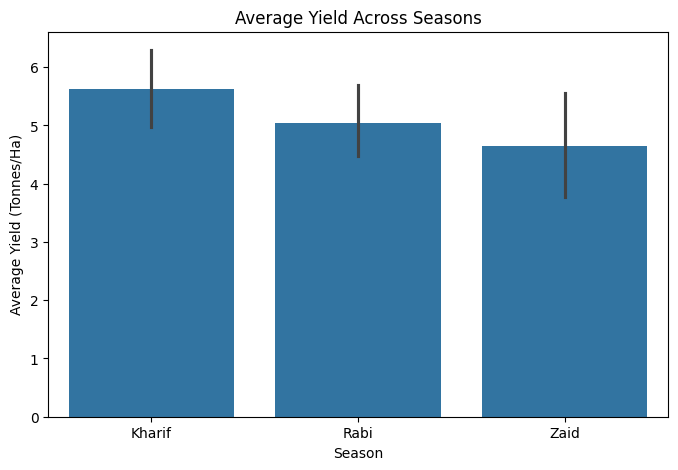

In [75]:
# Average yield by season

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha',
    estimator='mean'
)

plt.title('Average Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

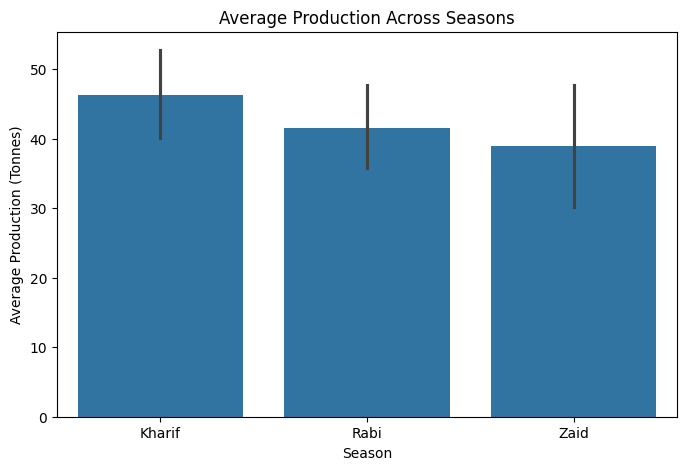

In [76]:
# Average production by season

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Production_Tonnes',
    estimator='mean'
)

plt.title('Average Production Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')

plt.show()

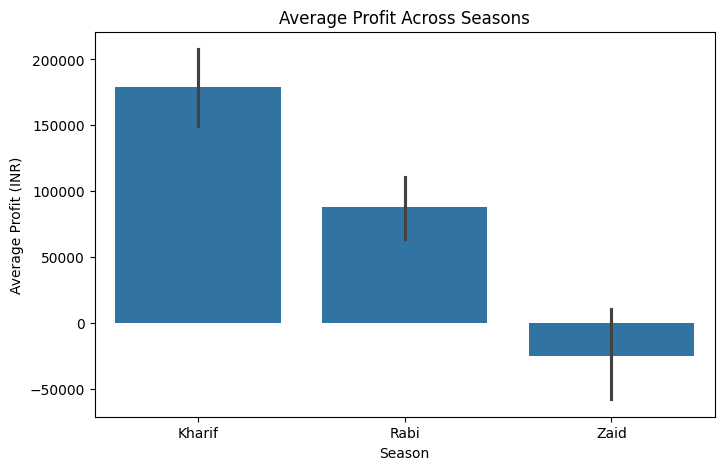

In [77]:
# Average profit by season

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Profit_INR',
    estimator='mean'
)

plt.title('Average Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.show()

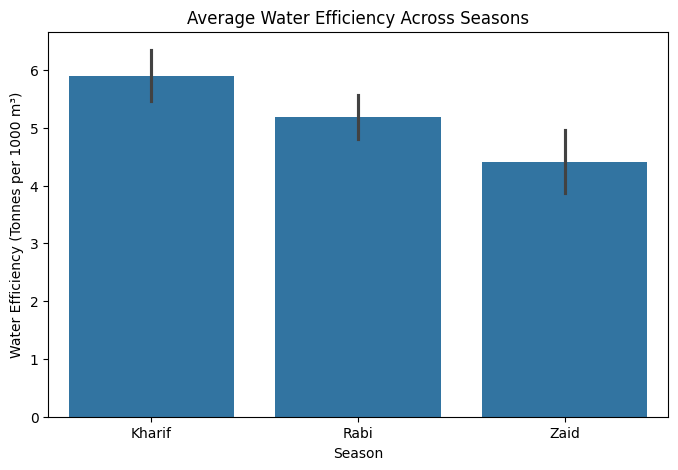

In [78]:
# Average water efficiency by season

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Water_Efficiency_t_per_1000m3',
    estimator='mean'
)

plt.title('Average Water Efficiency Across Seasons')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')

plt.show()

## 10. Initial Seasonal Performance Findings

The seasonal comparison shows noticeable differences in agricultural performance.

Kharif recorded the highest average yield, production, revenue, profit, and water efficiency among the three seasons. Its average yield was 5.63 tonnes per hectare and its average profit was approximately ₹178,915.

Rabi showed intermediate performance, with an average yield of 5.04 tonnes per hectare and an average profit of approximately ₹87,689.

Zaid recorded the lowest average yield, production, revenue, and water efficiency. The average profit during Zaid was negative at approximately ₹24,805, indicating that the average cost exceeded the average revenue in the available observations.

Zaid also recorded the highest average water usage while having the lowest water efficiency. These observations suggest that seasonal environmental conditions, resource utilization, crop composition, or economic factors may contribute to the observed differences.

Further analysis is required to investigate the factors associated with these seasonal differences.

## 11. Environmental Conditions Across Seasons

Environmental conditions can influence agricultural productivity and resource requirements. In this section, rainfall, temperature, humidity, sunlight, and soil moisture are compared across Kharif, Rabi, and Zaid seasons.

The purpose of this analysis is to identify seasonal environmental patterns and examine whether differences in environmental conditions may be associated with differences in agricultural performance.

In [79]:
# Calculate average environmental conditions by season

environmental_analysis = df.groupby('Season')[
    [
        'Rainfall_mm',
        'Avg_Temperature_C',
        'Humidity_pct',
        'Sunlight_Hours_Day',
        'Soil_Moisture_pct'
    ]
].mean().round(2)

environmental_analysis

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


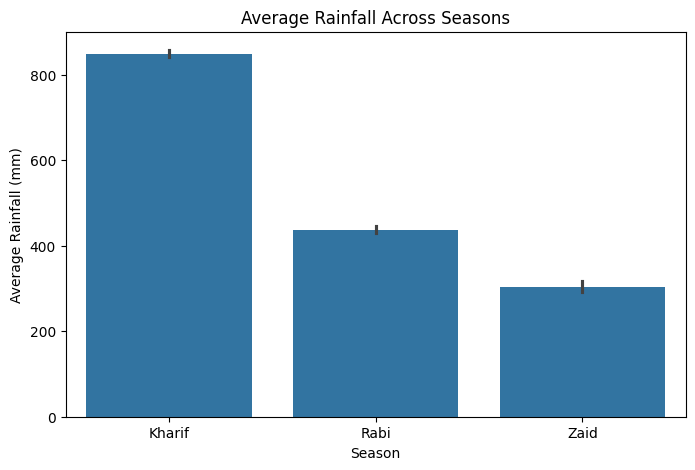

In [80]:
# Average rainfall by season

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Rainfall_mm',
    estimator='mean'
)

plt.title('Average Rainfall Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Rainfall (mm)')

plt.show()

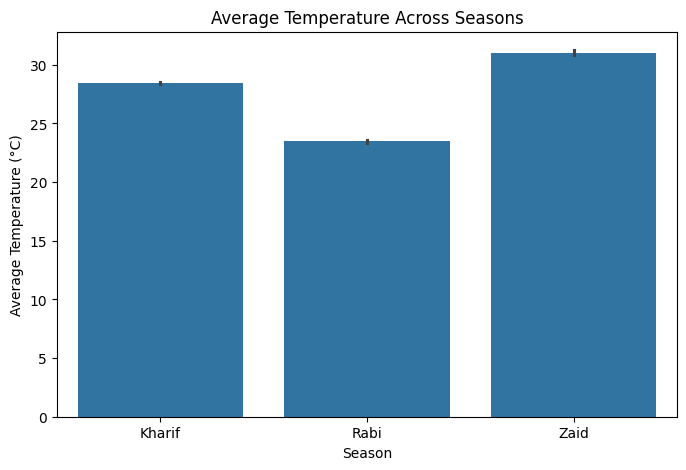

In [81]:
# Average temperature by season

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Avg_Temperature_C',
    estimator='mean'
)

plt.title('Average Temperature Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Temperature (°C)')

plt.show()

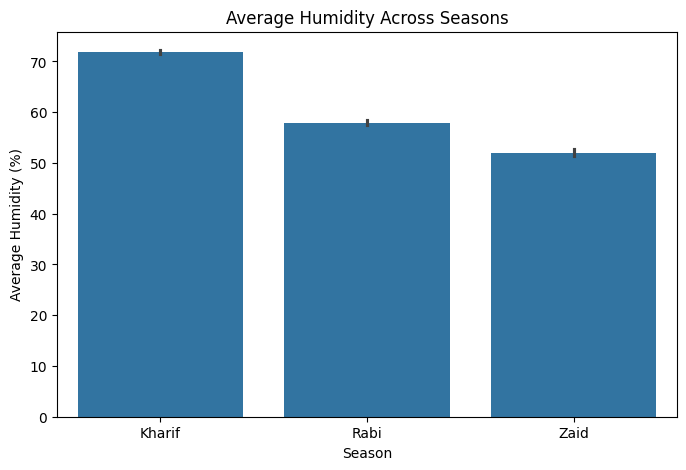

In [82]:
# Average humidity by season

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Humidity_pct',
    estimator='mean'
)

plt.title('Average Humidity Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Humidity (%)')

plt.show()

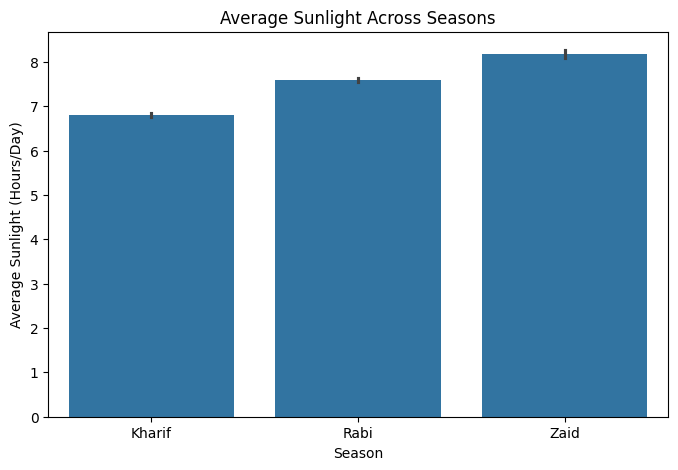

In [83]:
# Average sunlight by season

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Sunlight_Hours_Day',
    estimator='mean'
)

plt.title('Average Sunlight Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Sunlight (Hours/Day)')

plt.show()

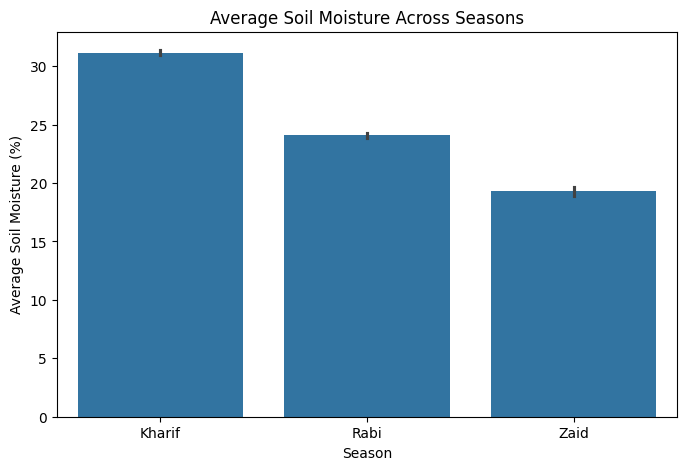

In [84]:
# Average soil moisture by season

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Soil_Moisture_pct',
    estimator='mean'
)

plt.title('Average Soil Moisture Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Soil Moisture (%)')

plt.show()

### Environmental Findings

The environmental analysis shows clear differences across the three agricultural seasons.

Kharif recorded the highest average rainfall (849.20 mm), humidity (71.81%), and soil moisture (31.15%). It also recorded the lowest average sunlight exposure at 6.79 hours per day.

Rabi experienced moderate environmental conditions, with an average rainfall of 437.62 mm, temperature of 23.49°C, humidity of 57.89%, and soil moisture of 24.07%.

Zaid recorded the lowest average rainfall (304.65 mm), humidity (52.01%), and soil moisture (19.28%), while having the highest average temperature (31.04°C) and sunlight exposure (8.18 hours per day).

These environmental differences occur alongside the differences in agricultural performance observed earlier. In particular, Zaid combines lower rainfall and soil moisture with higher temperature and water usage, which may be important factors to investigate further.

## 12. Resource Utilization Across Seasons

Agricultural productivity depends not only on environmental conditions but also on the efficient use of agricultural resources.

This section compares fertilizer, pesticide, nutrient, and water usage across seasons. The analysis also examines the distribution of irrigation methods to understand how resource management varies under different seasonal conditions.

In [85]:
# Calculate average resource usage by season

resource_analysis = df.groupby('Season')[
    [
        'Nitrogen_kg_ha',
        'Phosphorus_kg_ha',
        'Potassium_kg_ha',
        'Fertilizer_kg_ha',
        'Pesticide_Litre_ha',
        'Water_Used_m3'
    ]
].mean().round(2)

resource_analysis

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,6102.20
Rabi,120.40,57.31,103.93,185.41,5.02,5846.99
Zaid,120.53,58.13,105.42,184.64,5.17,6419.89


### Resource Utilization Findings

The resource utilization analysis shows that nutrient and agricultural input usage is relatively similar across the three seasons.

Average nitrogen usage ranges from 120.02 to 120.53 kg/ha, while phosphorus and potassium usage also show relatively small seasonal differences. Fertilizer and pesticide usage remain broadly comparable across seasons.

Water usage, however, shows a more noticeable difference. Zaid records the highest average water usage at 6,419.89 m³, followed by Kharif at 6,102.20 m³ and Rabi at 5,846.99 m³.

The higher water usage observed during Zaid is particularly notable because Zaid also has the lowest average rainfall, lowest soil moisture, and highest average temperature. This suggests that irrigation requirements may be greater during Zaid and warrants further investigation.

In [86]:
# Count irrigation methods by season

irrigation_counts = pd.crosstab(
    df['Season'],
    df['Irrigation_Method']
)

irrigation_counts

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


In [87]:
# Calculate irrigation method percentages within each season

irrigation_percentage = pd.crosstab(
    df['Season'],
    df['Irrigation_Method'],
    normalize='index'
) * 100

irrigation_percentage.round(2)

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


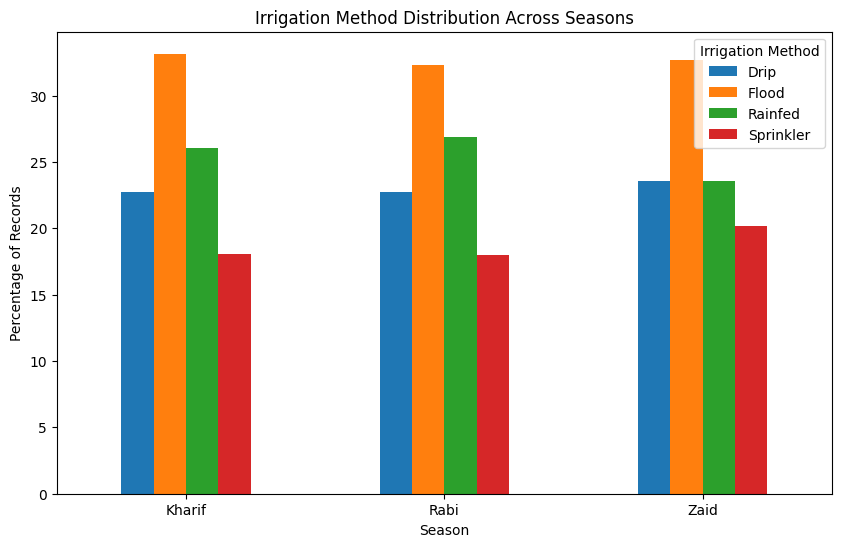

In [88]:
# Visualize irrigation methods across seasons

irrigation_percentage.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Irrigation Method Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Percentage of Records')
plt.xticks(rotation=0)
plt.legend(title='Irrigation Method')
plt.show()

### Irrigation Method Findings

The distribution of irrigation methods is relatively similar across the three seasons.

Flood irrigation is the most commonly observed method in Kharif, Rabi, and Zaid, accounting for 33.16%, 32.33%, and 32.66% of observations respectively.

Drip irrigation represents approximately 23% of observations across all seasons. Sprinkler irrigation has a slightly higher representation in Zaid at 20.20%, while rainfed agriculture has a lower representation in Zaid at 23.57% compared with Rabi at 26.92%.

Overall, the irrigation method distribution does not show a substantial seasonal difference. Therefore, the higher water usage observed in Zaid cannot be attributed to a major change in irrigation-method distribution based on this analysis alone.

## 13. Economic Performance Across Seasons

Economic performance is an important component of agricultural performance. In this section, market price, total production cost, revenue, and profit are compared across seasons.

The objective is to determine whether economic outcomes differ between Kharif, Rabi, and Zaid and to identify seasons with relatively higher or lower financial performance.

In [89]:
# Calculate average economic performance by season

economic_analysis = df.groupby('Season')[
    [
        'Market_Price_INR_Tonne',
        'Total_Cost_INR',
        'Revenue_INR',
        'Profit_INR'
    ]
].mean().round(2)

economic_analysis

,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,
Kharif,44850.91,531804.41,710719.06,178914.65
Rabi,44747.97,513836.58,601526.05,87689.47
Zaid,44212.03,543976.73,519171.90,-24804.82


### Economic Findings

The economic analysis reveals substantial differences in financial performance across seasons.

Kharif records the highest average revenue of approximately ₹710,719 and the highest average profit of approximately ₹178,915. Rabi records an average revenue of approximately ₹601,526 and an average profit of approximately ₹87,689.

Zaid shows the weakest economic performance, with an average revenue of approximately ₹519,172 and an average profit of approximately -₹24,805. Zaid also has the highest average total cost at approximately ₹543,977.

The average market prices across the three seasons are relatively similar, ranging from approximately ₹44,212 to ₹44,851 per tonne. Therefore, the large difference in profitability does not appear to be explained by market price differences alone.

The lower profitability of Zaid may instead be associated with its lower agricultural productivity and higher average cost. Further analysis is required to investigate the relationship between productivity, costs, resource usage, and profit.

## 14. Crop-wise Seasonal Analysis

Agricultural performance can vary considerably between crops. Therefore, seasonal comparisons should also consider crop composition.

This section examines the distribution of crops across seasons and compares average yield and profit for different crops and seasons. This helps determine whether the observed seasonal differences are consistent across crops or may be influenced by the types of crops cultivated.

In [90]:
# Number of records for each crop in each season

crop_season_counts = pd.crosstab(
    df['Season'],
    df['Crop']
)

crop_season_counts

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,185,215,193,234,221,314,125,292
Rabi,163,201,177,233,213,274,129,237
Zaid,64,92,54,84,62,102,51,85


In [91]:
# Percentage distribution of crops within each season

crop_season_percentage = pd.crosstab(
    df['Season'],
    df['Crop'],
    normalize='index'
) * 100

crop_season_percentage.round(2)

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,10.40,12.09,10.85,13.15,12.42,17.65,7.03,16.41
Rabi,10.02,12.35,10.88,14.32,13.09,16.84,7.93,14.57
Zaid,10.77,15.49,9.09,14.14,10.44,17.17,8.59,14.31


### Crop Distribution Findings

The crop distribution analysis shows that the composition of crops is relatively similar across the three seasons, although some differences are present.

Rice is the most represented crop category across all three seasons, accounting for 17.65% of Kharif observations, 16.84% of Rabi observations, and 17.17% of Zaid observations.

Cotton has a relatively higher representation in Zaid at 15.49%, compared with 12.09% in Kharif and 12.35% in Rabi. Wheat is more represented in Kharif at 16.41%, while Pulses have their highest representation in Rabi at 13.09%.

Overall, the crop composition does not show extremely large differences between seasons. Therefore, crop distribution alone may not fully explain the observed differences in seasonal agricultural performance. Further crop-wise performance analysis is required.

In [92]:
# Calculate average yield for each crop across seasons

crop_season_yield = df.groupby(
    ['Crop', 'Season']
)['Yield_Tonnes_Ha'].mean().unstack()

crop_season_yield.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


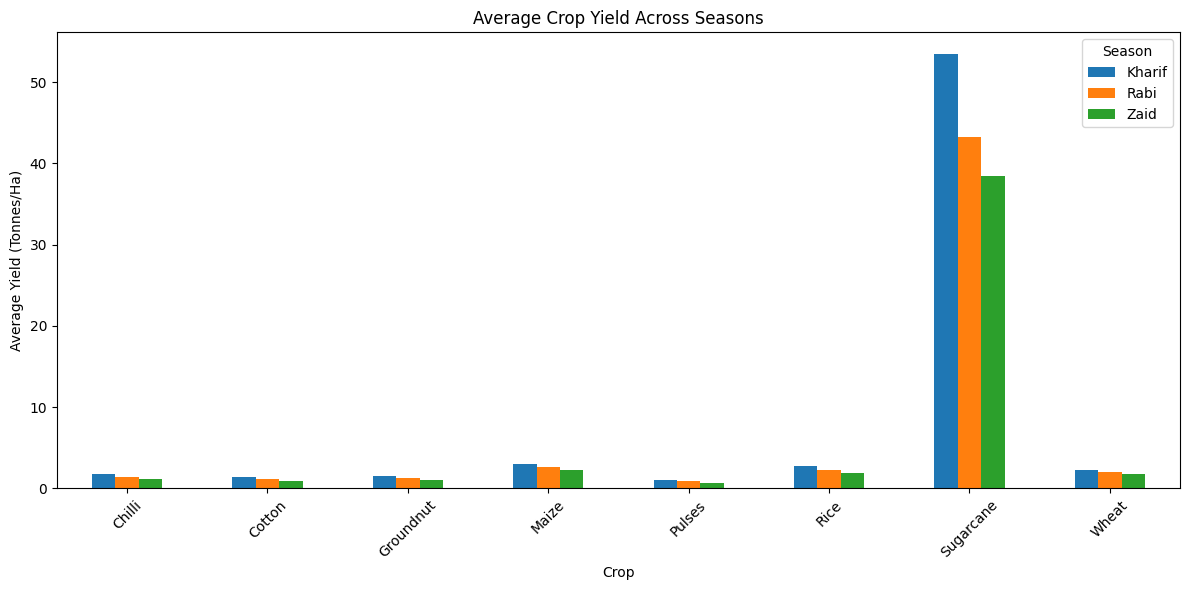

In [93]:
# Visualize average yield by crop and season

crop_season_yield.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

### Crop-wise Yield Findings

The crop-wise seasonal analysis reveals a consistent pattern across all eight crop categories.

For every crop in the dataset, the highest average yield is observed during Kharif, followed by Rabi, while the lowest average yield is observed during Zaid.

For example, average maize yield decreases from 2.97 tonnes/ha in Kharif to 2.60 tonnes/ha in Rabi and 2.29 tonnes/ha in Zaid. Similarly, rice yield decreases from 2.70 tonnes/ha in Kharif to 2.32 tonnes/ha in Rabi and 1.90 tonnes/ha in Zaid.

Sugarcane has substantially higher yield values than the other crops, reaching 53.46 tonnes/ha during Kharif, 43.29 tonnes/ha during Rabi, and 38.42 tonnes/ha during Zaid.

The consistent decline in yield from Kharif to Rabi and Zaid across all crop categories suggests that seasonal conditions may be an important factor associated with agricultural productivity. Further statistical analysis will be performed to determine whether these seasonal differences are statistically significant.

## 15. Regional Seasonal Analysis

Agricultural performance can vary across geographical regions because of differences in climate, soil characteristics, farming practices, and resource availability.

This section examines whether the seasonal differences in agricultural yield are consistent across different states.

In [94]:
# Calculate average yield by state and season

state_season_yield = df.groupby(
    ['State', 'Season']
)['Yield_Tonnes_Ha'].mean().unstack()

state_season_yield.round(2)

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.45
Gujarat,6.34,5.44,4.07
Karnataka,6.46,4.57,6.62
Madhya Pradesh,5.99,3.76,5.48
Maharashtra,5.43,5.50,2.28
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.78,4.25


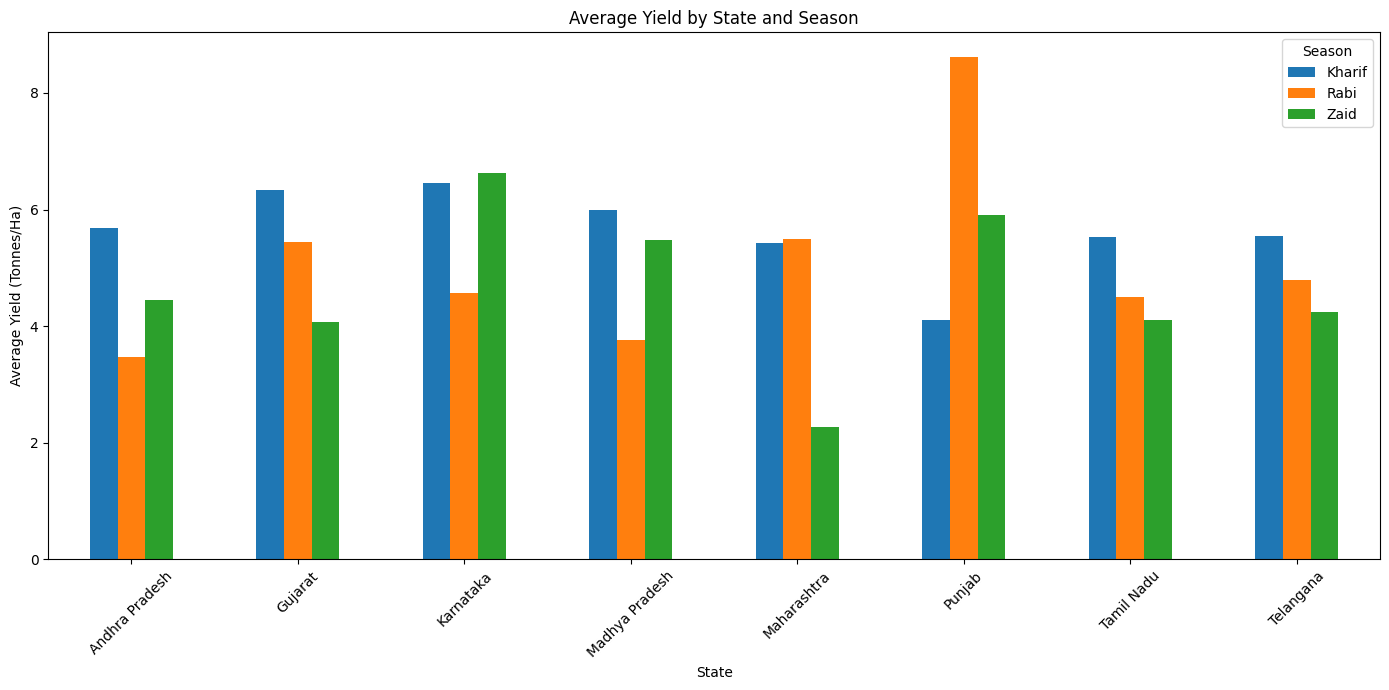

In [95]:
# Visualize average yield by state and season

state_season_yield.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Average Yield by State and Season')
plt.xlabel('State')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

### Regional Seasonal Findings

The state-level analysis reveals substantial geographical variation in seasonal agricultural performance.

Although Kharif has the highest overall average yield, the seasonal pattern is not consistent across all states.

Punjab records its highest average yield during Rabi at 8.61 tonnes/ha, while Karnataka records its highest average yield during Zaid at 6.62 tonnes/ha. Maharashtra also shows slightly higher average yield during Rabi than Kharif.

In contrast, Andhra Pradesh, Gujarat, Madhya Pradesh, Tamil Nadu, and Telangana record their highest average yields during Kharif.

These findings indicate that seasonal agricultural performance varies across geographical regions. Therefore, conclusions based only on overall seasonal averages may not fully represent regional agricultural conditions.

## 16. Correlation Analysis

Correlation analysis is used to examine the strength and direction of relationships between numerical variables.

The analysis helps identify variables that may be associated with agricultural productivity, economic performance, and resource efficiency.

Correlation does not imply causation; therefore, the results are interpreted as associations rather than direct cause-and-effect relationships.

In [96]:
# Select important numerical variables for correlation analysis

correlation_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3'
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix.round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Rainfall_mm,1.00,0.20,0.52,-0.36,0.51,0.01,0.02,0.03,0.02,0.00,0.03,0.02,0.10,0.11,0.00,0.06
Avg_Temperature_C,0.20,1.00,0.14,-0.03,0.08,0.02,0.01,0.02,0.02,0.01,0.01,0.01,0.03,0.01,0.02,0.01
Humidity_pct,0.52,0.14,1.00,-0.30,0.45,0.00,-0.01,-0.00,0.02,-0.00,0.01,0.00,0.06,0.06,-0.00,0.03
Sunlight_Hours_Day,-0.36,-0.03,-0.30,1.00,-0.30,0.01,0.00,-0.01,-0.01,-0.02,-0.02,-0.02,-0.05,-0.05,-0.01,-0.02
Soil_Moisture_pct,0.51,0.08,0.45,-0.30,1.00,0.01,0.01,0.01,0.01,-0.02,0.01,0.00,0.08,0.09,0.00,0.03
Nitrogen_kg_ha,0.01,0.02,0.00,0.01,0.01,1.00,0.01,0.01,-0.03,0.01,0.05,0.05,0.08,0.09,0.02,0.05
Phosphorus_kg_ha,0.02,0.01,-0.01,0.00,0.01,0.01,1.00,0.00,0.01,-0.03,0.05,0.03,0.03,0.05,-0.00,0.06
Potassium_kg_ha,0.03,0.02,-0.00,-0.01,0.01,0.01,0.00,1.00,0.02,-0.00,0.00,0.00,0.03,0.03,0.00,0.01
Fertilizer_kg_ha,0.02,0.02,0.02,-0.01,0.01,-0.03,0.01,0.02,1.00,-0.00,0.00,0.00,0.01,-0.07,0.00,0.01
Pesticide_Litre_ha,0.00,0.01,-0.00,-0.02,-0.02,0.01,-0.03,-0.00,-0.00,1.00,-0.01,-0.01,-0.00,-0.03,0.00,-0.01


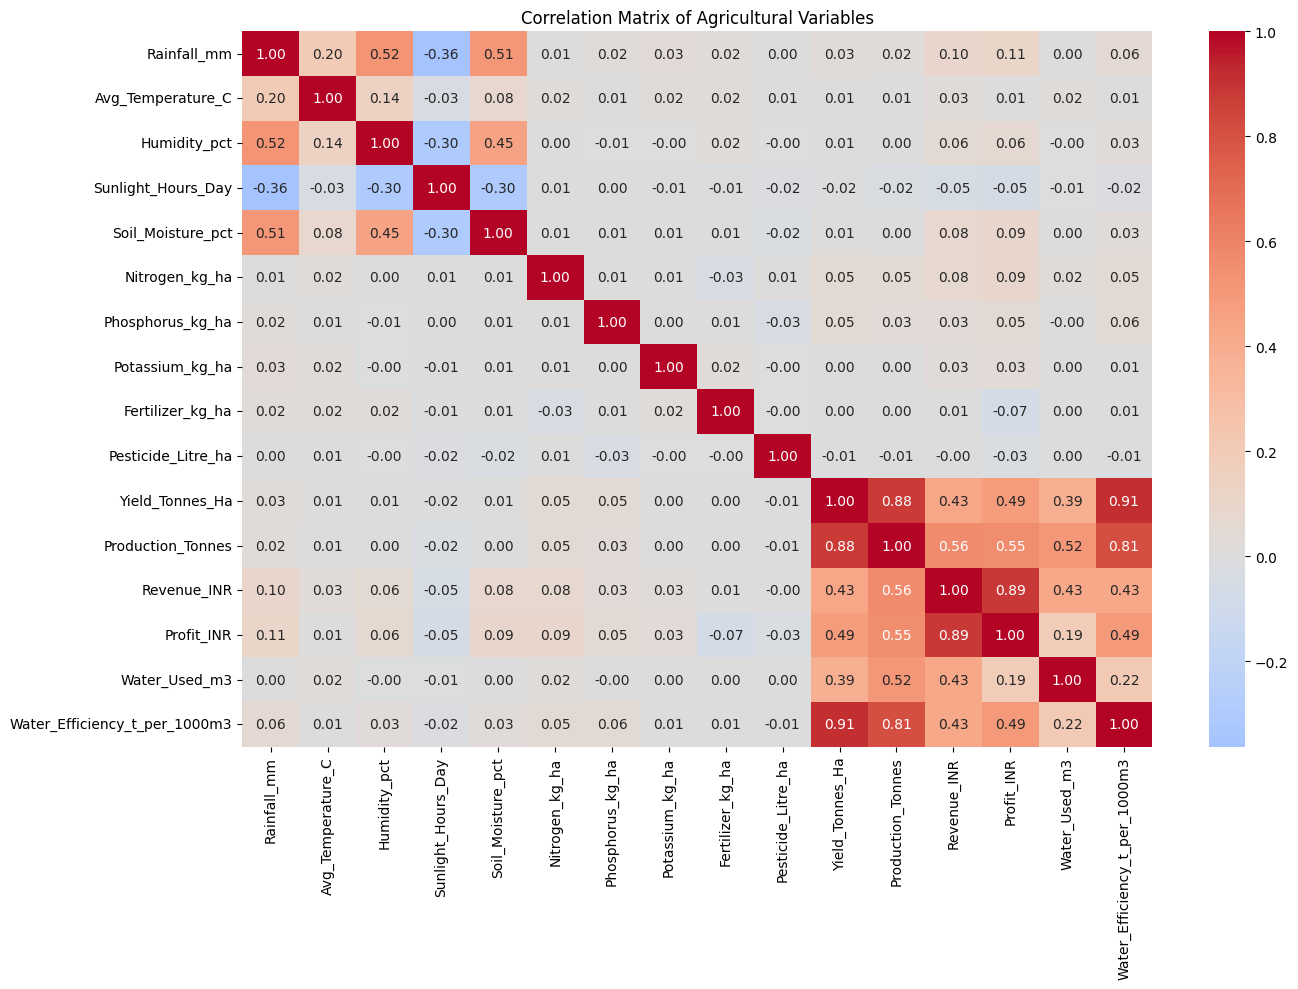

In [97]:
# Visualize the correlation matrix

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Agricultural Variables')
plt.tight_layout()
plt.show()

### Correlation Findings

The correlation analysis shows that agricultural productivity and economic performance have several notable relationships.

Yield has a very strong positive correlation with Water Efficiency (r = 0.91) and a strong positive correlation with Production (r = 0.88). Yield also shows moderate positive correlations with Profit (r = 0.49), Revenue (r = 0.43), and Water Used (r = 0.39).

Profit has a very strong positive correlation with Revenue (r = 0.89) and moderate positive correlations with Production (r = 0.55), Yield (r = 0.49), and Water Efficiency (r = 0.49).

In contrast, environmental and input variables such as rainfall, temperature, soil moisture, nitrogen, phosphorus, potassium, fertilizer, and pesticide show relatively weak correlations with yield in the overall dataset.

The strong correlation between Yield and Water Efficiency should be interpreted carefully because water efficiency is derived using yield. Therefore, this relationship does not establish a causal effect of water efficiency on yield.

Correlation measures association rather than causation, so further statistical analysis is required to determine whether seasonal differences in agricultural performance are statistically significant.

## 17. Statistical Testing of Seasonal Yield Differences

Descriptive analysis showed differences in average yield across Kharif, Rabi, and Zaid seasons.

A one-way Analysis of Variance (ANOVA) is performed to determine whether the mean yield differs significantly across the three seasons.

The null hypothesis (H₀) states that the mean yield is equal across all seasons.

The alternative hypothesis (H₁) states that at least one season has a different mean yield.

A significance level of 0.05 is used.

In [98]:
from scipy.stats import f_oneway

# Separate yield values by season

kharif_yield = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha'].dropna()
rabi_yield = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha'].dropna()
zaid_yield = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha'].dropna()

# Perform one-way ANOVA

anova_stat, p_value = f_oneway(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("ANOVA F-statistic:", round(anova_stat, 4))
print("p-value:", round(p_value, 6))

if p_value < 0.05:
    print("Result: Reject the null hypothesis.")
    print("There is a statistically significant difference in mean yield across seasons.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in mean yield across seasons.")

ANOVA F-statistic: 1.5439
p-value: 0.213678
Result: Fail to reject the null hypothesis.
There is no statistically significant difference in mean yield across seasons.


In [99]:
from scipy.stats import f_oneway

# Separate profit values by season

kharif_profit = df[df['Season'] == 'Kharif']['Profit_INR'].dropna()
rabi_profit = df[df['Season'] == 'Rabi']['Profit_INR'].dropna()
zaid_profit = df[df['Season'] == 'Zaid']['Profit_INR'].dropna()

# Perform one-way ANOVA on profit

profit_anova_stat, profit_p_value = f_oneway(
    kharif_profit,
    rabi_profit,
    zaid_profit
)

print("Profit ANOVA F-statistic:", round(profit_anova_stat, 4))
print("Profit ANOVA p-value:", round(profit_p_value, 6))

if profit_p_value < 0.05:
    print("Result: Reject the null hypothesis.")
    print("There is a statistically significant difference in mean profit across seasons.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in mean profit across seasons.")

Profit ANOVA F-statistic: 34.2918
Profit ANOVA p-value: 0.0
Result: Reject the null hypothesis.
There is a statistically significant difference in mean profit across seasons.


### Statistical Testing Findings

One-way ANOVA was performed separately for yield and profit to determine whether the differences across seasons were statistically significant.

For yield, the ANOVA produced an F-statistic of 1.5439 and a p-value of 0.213678. Since the p-value is greater than 0.05, the null hypothesis was not rejected. Therefore, the analysis does not provide statistically significant evidence that mean yield differs across Kharif, Rabi, and Zaid seasons.

For profit, the ANOVA produced an F-statistic of 34.2918 with a p-value effectively equal to zero. Since the p-value is below 0.05, the null hypothesis was rejected. This provides statistically significant evidence that mean agricultural profit differs across seasons.

These results indicate that seasonal differences are more strongly reflected in economic performance than in yield alone within this dataset.

In [100]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey's HSD test for profit

tukey_profit = pairwise_tukeyhsd(
    endog=df['Profit_INR'].dropna(),
    groups=df.loc[df['Profit_INR'].notna(), 'Season'],
    alpha=0.05
)

print(tukey_profit)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff   p-adj    lower        upper     reject
-----------------------------------------------------------------
Kharif   Rabi  -91225.1774   0.0 -134704.3086  -47746.0461   True
Kharif   Zaid -203719.4725   0.0 -263782.6023 -143656.3426   True
  Rabi   Zaid -112494.2951   0.0 -173255.6664  -51732.9238   True
-----------------------------------------------------------------


### Tukey HSD Post-hoc Findings

Since the one-way ANOVA indicated a statistically significant difference in mean profit across seasons, Tukey's HSD post-hoc test was performed to identify which seasonal pairs differed significantly.

The results show statistically significant differences between every pair of seasons at the 5% significance level.

Kharif and Rabi differ significantly in mean profit, with Kharif having approximately ₹91,225 higher average profit than Rabi.

Kharif and Zaid also differ significantly, with Kharif having approximately ₹203,719 higher average profit than Zaid.

Rabi and Zaid differ significantly as well, with Rabi having approximately ₹112,494 higher average profit than Zaid.

Therefore, the statistical analysis provides strong evidence that agricultural profitability differs across all three seasons, with the observed ranking being Kharif > Rabi > Zaid.

## 18. Key Findings

The analysis of 4,000 agricultural observations across Kharif, Rabi, and Zaid seasons produced the following key findings:

1. **Seasonal performance differs descriptively:** Kharif recorded the highest average yield at 5.63 tonnes/ha, followed by Rabi at 5.04 tonnes/ha and Zaid at 4.64 tonnes/ha.

2. **Environmental conditions vary considerably across seasons:** Kharif had the highest rainfall, humidity, and soil moisture, while Zaid had the highest temperature and sunlight and the lowest rainfall, humidity, and soil moisture.

3. **Water usage varies across seasons:** Zaid recorded the highest average water usage at 6,419.89 m³, while Rabi recorded the lowest at 5,846.99 m³.

4. **Resource usage is relatively similar:** Nitrogen, phosphorus, potassium, fertilizer, and pesticide usage showed only relatively small differences across seasons.

5. **Irrigation methods are broadly similar:** Flood irrigation was the most common method in all three seasons. The overall distribution of irrigation methods did not show major seasonal differences.

6. **Economic performance shows substantial seasonal variation:** Kharif recorded the highest average profit at approximately ₹178,915, while Zaid recorded a negative average profit of approximately ₹24,805.

7. **Crop-wise analysis shows a consistent descriptive pattern:** Every crop recorded its highest average yield during Kharif and lowest average yield during Zaid.

8. **Regional patterns are not uniform:** While several states recorded their highest yield during Kharif, Punjab performed best during Rabi and Karnataka recorded its highest average yield during Zaid.

9. **Correlation analysis identified important relationships:** Yield had a strong positive correlation with production, while profit had a very strong positive correlation with revenue.

10. **Statistical testing produced different conclusions for yield and profit:** ANOVA did not find a statistically significant difference in mean yield across seasons (p = 0.213678). However, ANOVA found a statistically significant difference in mean profit across seasons (F = 34.2918, p < 0.001).

11. **Tukey's HSD test confirmed pairwise profit differences:** Kharif, Rabi, and Zaid each differed significantly from the other seasons in terms of mean profit.

## 19. Recommendations

Based on the findings from the dataset, the following recommendations can be considered:

1. **Improve seasonal resource planning:** Resource requirements should be planned according to seasonal environmental conditions, particularly during periods with lower rainfall and soil moisture.

2. **Focus on water-use efficiency:** The higher water usage observed during Zaid, combined with lower water efficiency, suggests that efficient irrigation and water management should receive greater attention during this season.

3. **Investigate the causes of lower Zaid profitability:** Since Zaid recorded negative average profit and statistically significant differences in profitability, further investigation should focus on production costs, yield, water requirements, and crop-specific economics.

4. **Use region-specific strategies:** Seasonal performance differs across states. Agricultural planning should therefore consider local geographical and environmental conditions rather than applying the same seasonal strategy everywhere.

5. **Monitor crop-specific performance:** Since crop yields vary across seasons, farmers and planners should evaluate crop suitability according to seasonal and regional conditions.

6. **Optimize input utilization:** Nutrient and agricultural input usage was relatively similar across seasons. Further analysis could investigate whether input levels are appropriately matched with crop requirements and productivity.

7. **Support evidence-based planning:** Agricultural decisions should consider multiple factors including environmental conditions, resource usage, productivity, costs, and profitability rather than relying on a single performance measure.

## 20. Limitations

The analysis has several limitations that should be considered when interpreting the results:

1. The analysis is based only on the variables available in the provided dataset.

2. Correlation analysis identifies associations between variables but does not establish cause-and-effect relationships.

3. The one-way ANOVA for yield did not find statistically significant differences across seasons. Therefore, the observed differences in average yield should not be interpreted as statistically proven seasonal effects.

4. The analysis does not account for all possible factors that may influence agricultural performance, such as farm-level management practices, soil characteristics, weather events, labor availability, or market fluctuations beyond the available variables.

5. The dataset covers selected states, districts, crops, and seasons. Therefore, the findings should not automatically be generalized to all agricultural regions.

6. Some variables contain missing observations, which were handled during the data-cleaning process.

7. Outlier detection was performed to identify unusual observations, but not every statistical outlier was automatically removed because extreme values may represent genuine agricultural conditions.

8. The results describe patterns present in the dataset and should be combined with domain knowledge and additional agricultural data for real-world decision-making.

## 21. Conclusion

This project analyzed agricultural data from Kharif, Rabi, and Zaid seasons to identify seasonal patterns, relationships, variations, and differences in agricultural performance.

The analysis showed clear descriptive differences in environmental conditions, resource usage, productivity, and economic outcomes across seasons. Kharif recorded the highest average yield and profit, while Zaid recorded the lowest average yield and negative average profit.

Environmental analysis showed that Kharif had higher rainfall, humidity, and soil moisture, whereas Zaid experienced lower rainfall and soil moisture along with higher temperature and sunlight. Zaid also recorded the highest average water usage.

Crop-wise analysis showed that all eight crop categories had their highest observed average yield during Kharif and lowest during Zaid. However, state-level analysis demonstrated that seasonal patterns can vary substantially across regions, with Punjab performing best during Rabi and Karnataka performing best during Zaid.

Correlation analysis identified important associations among productivity, production, revenue, profit, and water efficiency. However, these relationships were interpreted carefully because correlation does not establish causation.

Statistical testing provided an important distinction between descriptive patterns and statistically supported conclusions. One-way ANOVA did not identify a statistically significant difference in mean yield across seasons. In contrast, profit showed a statistically significant difference across seasons. Tukey's HSD test further showed that each pair of seasons differed significantly in mean profit.

Overall, the analysis indicates that seasonal differences are particularly important when considering agricultural profitability. The findings highlight the importance of efficient resource management, region-specific planning, water-use efficiency, and further investigation of the factors contributing to seasonal economic performance.